In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_2574457/4070851529.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


# 1 Load data from "2 BrainAge"

In [48]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Preprocessing and descriptives

## 2.1 Data

In [49]:
main_test.head()

,ID,Age,Gender,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,-3.423125,-5.895638,-0.921778
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,4.117294,-2.462486,4.928224
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,1.575519,-4.039160,-7.538266
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,-4.849877,-11.576884,1.849617
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,-5.096021,-4.403172,-4.413597


## 2.2 Remove outliers on SR PA

In [50]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


## 2.3 Convert SRPA from MET min/week to min/week

In [51]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Remove people with Gender other than Male or Female

In [52]:
before = main_test.shape[0]
main_test = main_test[(main_test["Gender"] == "Female") | (main_test["Gender"] == "Male")]
after = main_test.shape[0]
print("Gender not Male or Female:", before-after)
print(after)

Gender not Male or Female: 0
5422


## 2.5 Test set descriptives

In [53]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Mean 64.42456658059757
Std 7.746236362094369
LPA
Mean 1976.847024123939
Std 415.15230248082173
MPA
Mean 484.2255359645888
Std 223.43063077111645
VPA
Mean 33.850217041682065
Std 44.54301033256454
SRLPA
Mean 233.9857985983032
Std 216.24792076864688
SRMPA
Mean 158.63353006270748
Std 191.35229826700072
SRVPA
Mean 64.06307635558835
Std 82.60736773994667
DBP
Mean 81.12652157875323
Std 10.413487966847205
SBP
Mean 136.59553670232387
Std 18.801323470648573
BMI
Mean 26.338654463297672
Std 4.231620807724451
HG
Mean 33.6119513094799
Std 10.947389284412296
HR
Mean 67.9821099225378
Std 10.694628178678567
IS
11025    3330
11027    1151
11026     936
11028       5
Name: IS, dtype: int64


## 2.6 Train set descriptives

In [54]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Mean 64.42456658059757
Std 7.746236362094369
LPA
Mean 1976.847024123939
Std 415.15230248082173
MPA
Mean 484.2255359645888
Std 223.43063077111645
VPA
Mean 33.850217041682065
Std 44.54301033256454
SRLPA
Mean 233.9857985983032
Std 216.24792076864688
SRMPA
Mean 158.63353006270748
Std 191.35229826700072
SRVPA
Mean 64.06307635558835
Std 82.60736773994667
DBP
Mean 81.12652157875323
Std 10.413487966847205
SBP
Mean 136.59553670232387
Std 18.801323470648573
BMI
Mean 26.338654463297672
Std 4.231620807724451
HG
Mean 33.6119513094799
Std 10.947389284412296
HR
Mean 67.9821099225378
Std 10.694628178678567
IS
11025    3330
11027    1151
11026     936
11028       5
Name: IS, dtype: int64


## 2.7 Age and BrainAge

In [55]:
# # plot Age by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
# plt.title("Age x Gender")
# plt.show()

# # plot BrainAGE by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
# plt.title("BrainAge x Gender")
# plt.show()

# # plot BrainAGE by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
# plt.title("BrainAge x Imaging site")
# plt.show()

# # plot Age by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
# plt.title("Age x Imaging site")
# plt.show()

# # plot Moderate PA by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
# plt.title("Moderate PA x Imaging site")
# plt.show()

# # plot BrainAGE Segmentations
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
# sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
# sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
# plt.xlabel("BrainAGE", fontsize=14)
# plt.ylabel("Density", fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(fontsize=14)
# plt.show()

## 2.8 Physical activity

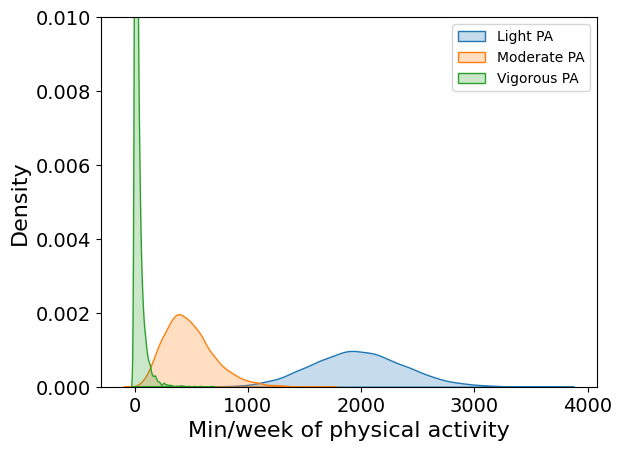

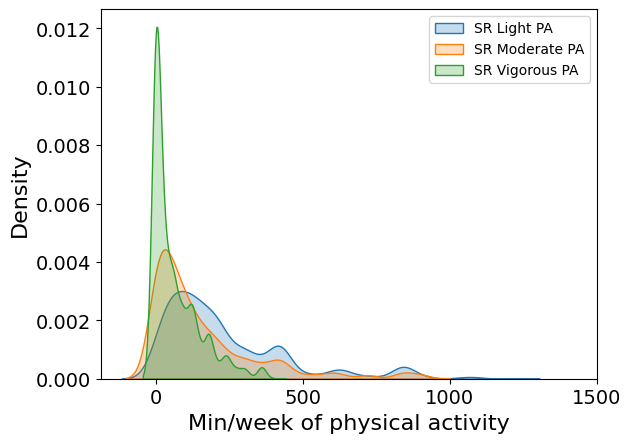

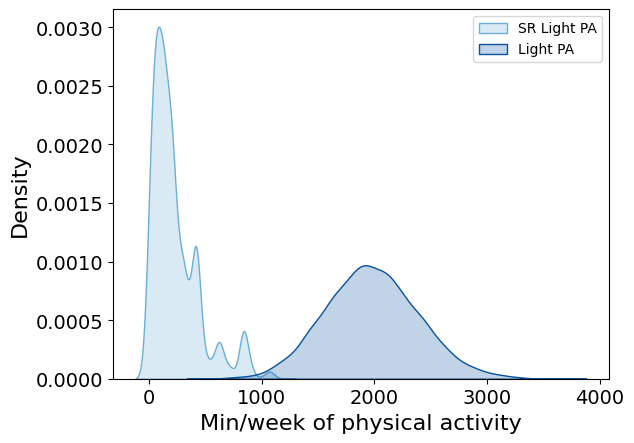

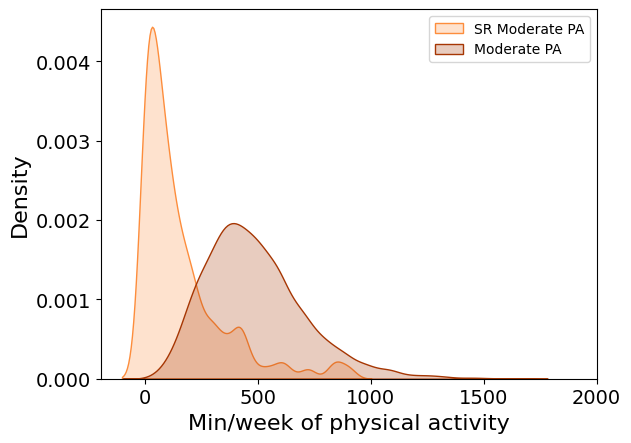

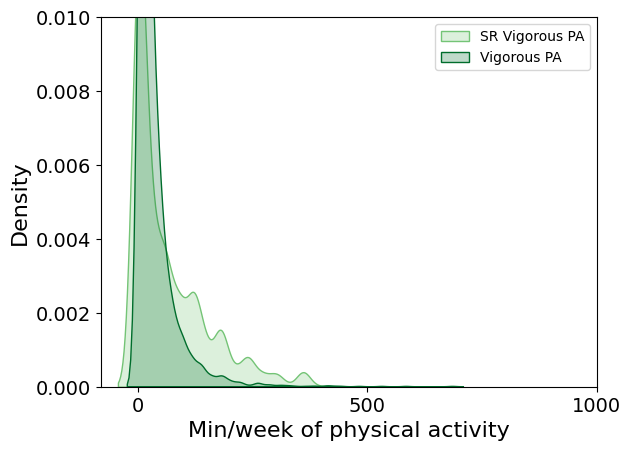

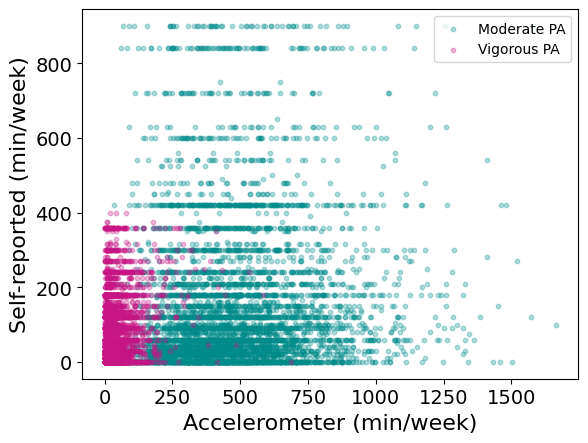

In [56]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
plt.ylim(0,0.01)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,4500,1000),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,1500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.legend()
plt.show()

plt.figure()
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.show()

## 2.9 Fitness

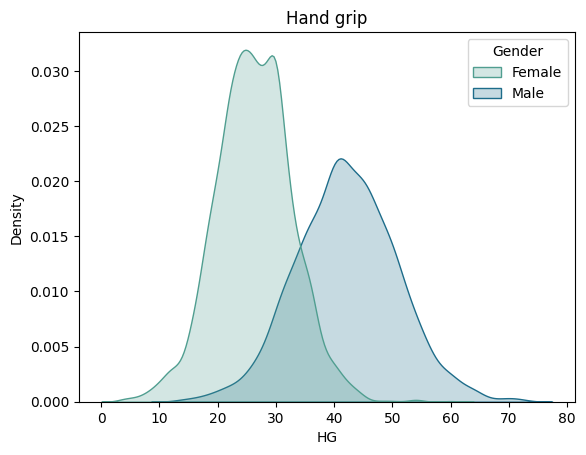

In [57]:
# plot dominant hand grip strength
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.10 Health

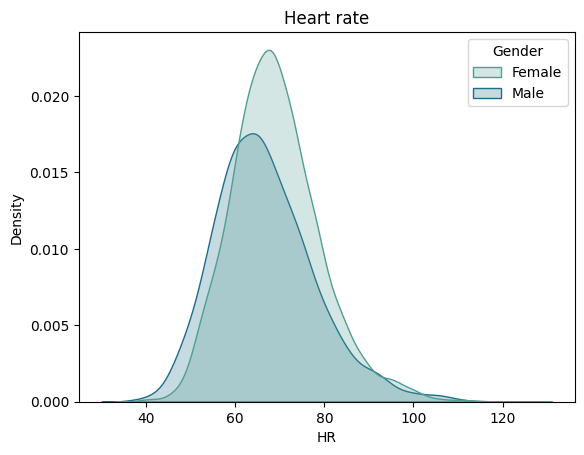

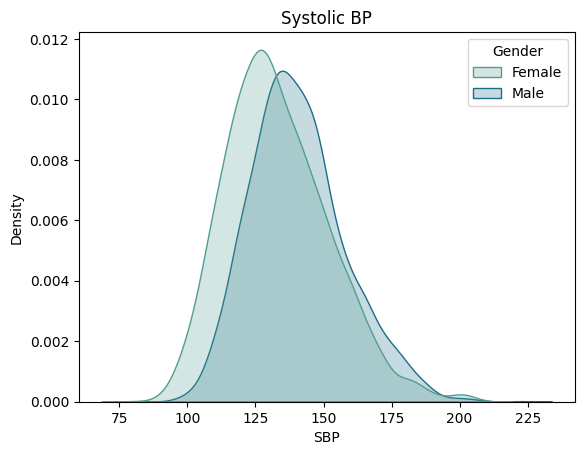

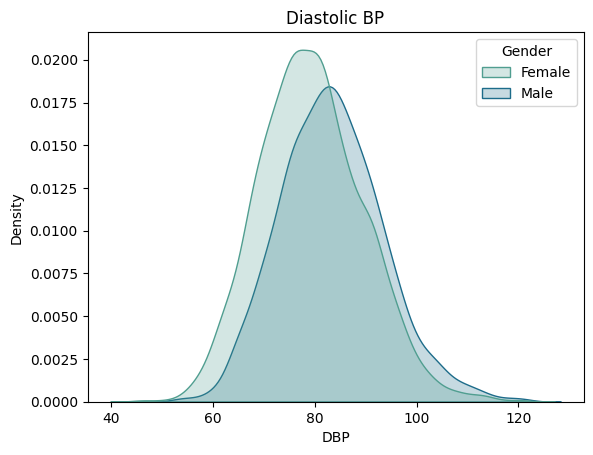

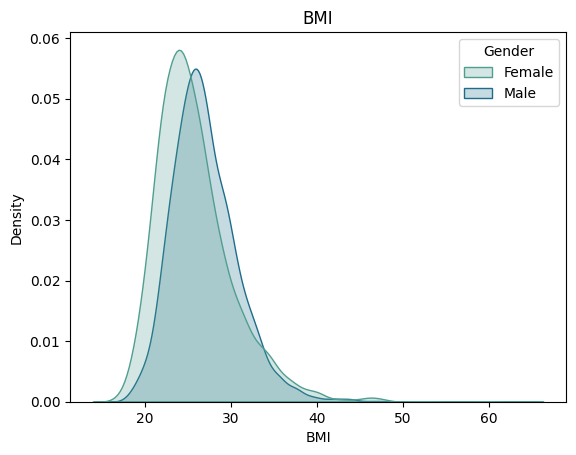

In [58]:
# plot Heart rate
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

# plot systolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

# plot diastolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Diastolic BP")
plt.show()

# plot BMI
plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

# 3 Recode and compute variables

## 3.1 Recode variables

In [59]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test = main_test.rename(columns={"BADA2009": "BA"})


## 3.3 Remove effect of Age on all predictor variables (regression -> residuals)

In [60]:
model = ols("LPA ~ Age", data = main_test).fit()
main_test["LPA"] = model.resid

model = ols("MPA ~ Age", data = main_test).fit()
main_test["MPA"] = model.resid

model = ols("VPA ~ Age", data = main_test).fit()
main_test["VPA"] = model.resid

model = ols("SRLPA ~ Age", data = main_test).fit()
main_test["SRLPA"] = model.resid

model = ols("SRMPA ~ Age", data = main_test).fit()
main_test["SRMPA"] = model.resid

model = ols("SRVPA ~ Age", data = main_test).fit()
main_test["SRVPA"] = model.resid

model = ols("HR ~ Age", data = main_test).fit()
main_test["HR"] = model.resid

model = ols("DBP ~ Age", data = main_test).fit()
main_test["DBP"] = model.resid

model = ols("SBP ~ Age", data = main_test).fit()
main_test["SBP"] = model.resid

model = ols("BMI ~ Age", data = main_test).fit()
main_test["BMI"] = model.resid

model = ols("HG ~ Age", data = main_test).fit()
main_test["HG"] = model.resid

# 4 Reorder dataframe and delete unused variables

In [61]:
main_test = main_test[['Age', 'Gender', 'IS' , 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Correlation heatmap

In [62]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

,Age,Gender,IS,LPA,MPA,VPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BA
Age,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9775
Gender,0.0,0.0,0.3298,0.0,0.0011,0.0,0.0178,0.0002,0.0,0.0,0.0,0.0,0.0,0.0,0.0017
IS,0.0,0.3298,0.0,0.0368,0.0017,0.0113,0.0003,0.7057,0.1238,0.4379,0.0102,0.2108,0.4153,0.0366,0.1758
LPA,1.0,0.0,0.0368,0.0,0.0,0.0,0.0,0.0,0.0003,0.0,0.2256,0.0,0.0,0.001,0.384
MPA,1.0,0.0011,0.0017,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,0.0,0.0,0.0,0.0008,0.0005
VPA,1.0,0.0,0.0113,0.0,0.0,0.0,0.1196,0.0039,0.0,0.0,0.0,0.0,0.0,0.0499,0.2401
SRLPA,1.0,0.0178,0.0003,0.0,0.0,0.1196,0.0,0.0,0.0,0.1762,0.002,0.0,0.3317,0.6353,0.7212
SRMPA,1.0,0.0002,0.7057,0.0,0.0,0.0039,0.0,0.0,0.0,0.4189,0.0,0.0,0.0022,0.293,0.738
SRVPA,1.0,0.0,0.1238,0.0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0633,0.2198,0.6768
HG,1.0,0.0,0.4379,0.0,0.0077,0.0,0.1762,0.4189,0.0,0.0,0.0,0.0,0.0,0.0,0.7434


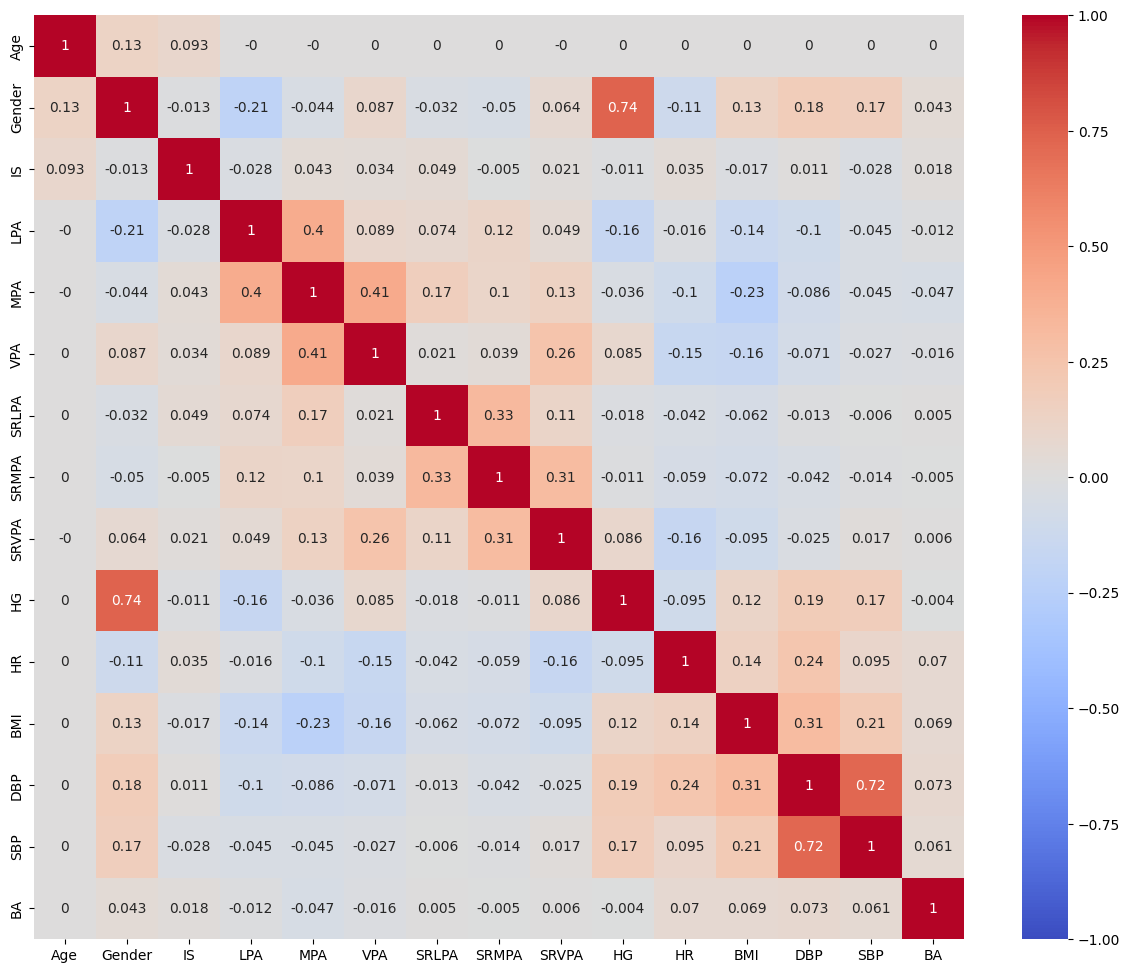

In [63]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)
calculate_pvalues(main_test)

# 6 Models OLS

## 6.1 Single Predictor Models

### 6.1.1 Accelerometer PA

In [64]:
mpa = ols('BA ~ MPA + Age + Gender + IS + Gender:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.957
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           0.000157
Time:                        16:40:43   Log-Likelihood:                -18339.
No. Observations:                5422   AIC:                         3.669e+04
Df Residuals:                    5416   BIC:                         3.673e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1553      0.811     -0.191      0.8

### 6.1.2 Self-report PA

In [65]:
srmpa = ols('BA ~ SRMPA + Age + Gender + IS + Gender:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.395
Date:                Sat, 17 Jun 2023   Prob (F-statistic):            0.00459
Time:                        16:40:46   Log-Likelihood:                -18342.
No. Observations:                5422   AIC:                         3.670e+04
Df Residuals:                    5416   BIC:                         3.674e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.1910      0.812     -0.235   

In [66]:
# srcr = ols('BA ~ SRCR + Age + Gender + IS + Gender:SRCR', missing='drop', data = main_test).fit()
# print(srcr.summary())

# #calculate effect size
# results = srcr
# coefficients = results.params
# stderr = results.bse
# effect_size = coefficients / (stderr* np.sqrt(5422))
# print(effect_size)

## 6.2 Multiple Predictor & Comparison Models

### 6.2.1 Covariates

In [67]:
cov_model = ols('BA ~ Gender + Age + IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.014
Date:                Sat, 17 Jun 2023   Prob (F-statistic):            0.00728
Time:                        16:41:00   Log-Likelihood:                -18345.
No. Observations:                5422   AIC:                         3.670e+04
Df Residuals:                    5418   BIC:                         3.672e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1678      0.812     -0.207      0.8

### 6.2.2 PAF / MPA

In [68]:
no_mpa = ols('BA ~ HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_mpa.summary())

#calculate effect size
results = no_mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     9.055
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           5.70e-15
Time:                        16:41:07   Log-Likelihood:                -18306.
No. Observations:                5422   AIC:                         3.663e+04
Df Residuals:                    5411   BIC:                         3.671e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8361      0.219     -3.822      0.0

### 6.2.3 PAF / HG

In [69]:
no_hg = ols('BA ~ MPA + DBP + HR + BMI + Gender + IS + MPA:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hg.summary())

#calculate effect size
results = no_hg
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.490
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           6.12e-12
Time:                        16:41:15   Log-Likelihood:                -18314.
No. Observations:                5422   AIC:                         3.665e+04
Df Residuals:                    5411   BIC:                         3.672e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5404      0.154     -3.519      0.0

### 6.2.4 PAF / HR

In [70]:
no_hr = ols('BA ~ HG + DBP + MPA + BMI + Gender + IS + HG:Gender + DBP:Gender + MPA:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hr.summary())

#calculate effect size
results = no_hr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.104
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           4.00e-13
Time:                        16:41:20   Log-Likelihood:                -18311.
No. Observations:                5422   AIC:                         3.664e+04
Df Residuals:                    5411   BIC:                         3.672e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8096      0.218     -3.707      0.0

### 6.2.5 PAF / DBP

In [71]:
no_dbp = ols('BA ~ HG + MPA + HR + BMI + Gender + IS + HG:Gender + MPA:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_dbp.summary())

#calculate effect size
results = no_dbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.465
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           7.99e-14
Time:                        16:41:28   Log-Likelihood:                -18309.
No. Observations:                5422   AIC:                         3.664e+04
Df Residuals:                    5411   BIC:                         3.671e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8600      0.219     -3.935      0.0

### 6.2.6 PAF / BMI

In [72]:
no_bmi = ols('BA ~ HG + DBP + HR + MPA + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(no_bmi.summary())

#calculate effect size
results = no_bmi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.540
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           5.72e-14
Time:                        16:41:36   Log-Likelihood:                -18308.
No. Observations:                5422   AIC:                         3.664e+04
Df Residuals:                    5411   BIC:                         3.671e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8454      0.219     -3.865      0.0

### 6.2.7 PAF

In [73]:
cr2 = ols('BA ~ MPA +HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(cr2.summary())

#calculate effect size
results = cr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.949
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           6.18e-15
Time:                        16:41:40   Log-Likelihood:                -18304.
No. Observations:                5422   AIC:                         3.663e+04
Df Residuals:                    5409   BIC:                         3.672e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8335      0.219     -3.809      0.0

### 6.2.8 SR PAF

In [74]:
srcr2 = ols('BA ~ SRMPA + HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + SRMPA:Gender', missing='drop', data = main_test).fit()
print(srcr2.summary())

#calculate effect size
results = srcr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.846
Date:                Sat, 17 Jun 2023   Prob (F-statistic):           1.07e-14
Time:                        16:41:46   Log-Likelihood:                -18304.
No. Observations:                5422   AIC:                         3.663e+04
Df Residuals:                    5409   BIC:                         3.672e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.8559      0.219     -3.908   

# 7 Model comparisons

## 7.1 Cov vs. PA

In [75]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  275729.845156      0.0         NaN       NaN       NaN
1    5416.0  275083.744875      2.0  646.100281  6.360389  0.001742


## 7.2 Cov vs. SRPA

In [76]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  275729.845156      0.0         NaN       NaN       NaN
1    5416.0  275479.361229      2.0  250.483926  2.462291  0.085335


## 7.3 PAF / MPA

In [77]:
model_comparison = anova_lm(no_mpa, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  271794.577918      0.0         NaN       NaN       NaN
1    5409.0  271553.688038      2.0  240.889879  2.399108  0.090896


## 7.4 SR PAF / SRMPA

In [78]:
model_comparison = anova_lm(no_mpa, srcr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  271794.577918      0.0         NaN       NaN       NaN
1    5409.0  271614.719228      2.0  179.858689  1.790874  0.166913


## 7.5 PAF / HG

In [79]:
model_comparison = anova_lm(no_hg, cr2)
print(model_comparison)

   df_resid            ssr  df_diff      ss_diff         F    Pr(>F)
0    5411.0  272569.876190      0.0          NaN       NaN       NaN
1    5409.0  271553.688038      2.0  1016.188152  10.12058  0.000041


## 7.6 PAF / DBP

In [80]:
model_comparison = anova_lm(no_dbp, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  272085.936061      0.0         NaN       NaN       NaN
1    5409.0  271553.688038      2.0  532.248023  5.300848  0.005013


## 7.7 PAF / HR

In [81]:
model_comparison = anova_lm(no_hr, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff        F    Pr(>F)
0    5411.0  272264.814304      0.0         NaN      NaN       NaN
1    5409.0  271553.688038      2.0  711.126266  7.08236  0.000848


## 7.8 PAF / BMI

In [82]:
model_comparison = anova_lm(no_bmi, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F   Pr(>F)
0    5411.0  272048.969480      0.0         NaN       NaN      NaN
1    5409.0  271553.688038      2.0  495.281441  4.932684  0.00724


# 8 Standardization of all variables

In [83]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS"]], nan_policy='omit')

# 9 Mediation analysis

## 9.1 BMI

In [84]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.066314       -0.100979       -0.035158    0.000
ACME (treated)           -0.066314       -0.100979       -0.035158    0.000
ADE (control)            -0.016618       -0.198401        0.167408    0.846
ADE (treated)            -0.016618       -0.198401        0.167408    0.846
Total effect             -0.082932       -0.267513        0.104015    0.402
Prop. mediated (control)  0.478248       -7.083436        7.006795    0.402
Prop. mediated (treated)  0.478248       -7.083436        7.006795    0.402
ACME (average)           -0.066314       -0.100979       -0.035158    0.000
ADE (average)            -0.016618       -0.198401        0.167408    0.846
Prop. mediated (average)  0.478248       -7.083436        7.006795    0.402


In [85]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.101898       -0.155605       -0.055907     0.00
ACME (treated)           -0.101898       -0.155605       -0.055907     0.00
ADE (control)            -0.234944       -0.434436       -0.044490     0.02
ADE (treated)            -0.234944       -0.434436       -0.044490     0.02
Total effect             -0.336842       -0.530250       -0.148912     0.00
Prop. mediated (control)  0.304800        0.141286        0.717008     0.00
Prop. mediated (treated)  0.304800        0.141286        0.717008     0.00
ACME (average)           -0.101898       -0.155605       -0.055907     0.00
ADE (average)            -0.234944       -0.434436       -0.044490     0.02
Prop. mediated (average)  0.304800        0.141286        0.717008     0.00


In [86]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA ", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.077773       -0.118355       -0.043849    0.000
ACME (treated)           -0.077773       -0.118355       -0.043849    0.000
ADE (control)            -0.034354       -0.231543        0.160396    0.712
ADE (treated)            -0.034354       -0.231543        0.160396    0.712
Total effect             -0.112126       -0.310681        0.090711    0.258
Prop. mediated (control)  0.528135       -5.906097        7.572672    0.258
Prop. mediated (treated)  0.528135       -5.906097        7.572672    0.258
ACME (average)           -0.077773       -0.118355       -0.043849    0.000
ADE (average)            -0.034354       -0.231543        0.160396    0.712
Prop. mediated (average)  0.528135       -5.906097        7.572672    0.258


## 9.2 DBP

In [87]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.051271       -0.083690       -0.024502    0.000
ACME (treated)           -0.051271       -0.083690       -0.024502    0.000
ADE (control)            -0.034416       -0.233572        0.162866    0.738
ADE (treated)            -0.034416       -0.233572        0.162866    0.738
Total effect             -0.085687       -0.285238        0.112178    0.368
Prop. mediated (control)  0.388388       -6.584432        6.607891    0.368
Prop. mediated (treated)  0.388388       -6.584432        6.607891    0.368
ACME (average)           -0.051271       -0.083690       -0.024502    0.000
ADE (average)            -0.034416       -0.233572        0.162866    0.738
Prop. mediated (average)  0.388388       -6.584432        6.607891    0.368


In [88]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.042604       -0.074416       -0.018317    0.000
ACME (treated)           -0.042604       -0.074416       -0.018317    0.000
ADE (control)            -0.296498       -0.477351       -0.110833    0.004
ADE (treated)            -0.296498       -0.477351       -0.110833    0.004
Total effect             -0.339102       -0.521132       -0.153435    0.002
Prop. mediated (control)  0.121213        0.049181        0.293214    0.002
Prop. mediated (treated)  0.121213        0.049181        0.293214    0.002
ACME (average)           -0.042604       -0.074416       -0.018317    0.000
ADE (average)            -0.296498       -0.477351       -0.110833    0.004
Prop. mediated (average)  0.121213        0.049181        0.293214    0.002


In [89]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.037218       -0.066731       -0.012769    0.002
ACME (treated)           -0.037218       -0.066731       -0.012769    0.002
ADE (control)            -0.075649       -0.281542        0.108340    0.454
ADE (treated)            -0.075649       -0.281542        0.108340    0.454
Total effect             -0.112867       -0.323524        0.080626    0.260
Prop. mediated (control)  0.253118       -4.354883        3.033678    0.262
Prop. mediated (treated)  0.253118       -4.354883        3.033678    0.262
ACME (average)           -0.037218       -0.066731       -0.012769    0.002
ADE (average)            -0.075649       -0.281542        0.108340    0.454
Prop. mediated (average)  0.253118       -4.354883        3.033678    0.262


## 9.3 Heart rate

In [90]:
outcome_model = sm.OLS.from_formula("BA ~ HR + LPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.008298       -0.031783        0.013246    0.432
ACME (treated)           -0.008298       -0.031783        0.013246    0.432
ADE (control)            -0.075773       -0.276516        0.116917    0.400
ADE (treated)            -0.075773       -0.276516        0.116917    0.400
Total effect             -0.084071       -0.279913        0.107278    0.358
Prop. mediated (control)  0.059678       -0.856893        1.232204    0.582
Prop. mediated (treated)  0.059678       -0.856893        1.232204    0.582
ACME (average)           -0.008298       -0.031783        0.013246    0.432
ADE (average)            -0.075773       -0.276516        0.116917    0.400
Prop. mediated (average)  0.059678       -0.856893        1.232204    0.582


In [91]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.047281       -0.078572       -0.020628      0.0
ACME (treated)           -0.047281       -0.078572       -0.020628      0.0
ADE (control)            -0.289508       -0.473729       -0.098318      0.0
ADE (treated)            -0.289508       -0.473729       -0.098318      0.0
Total effect             -0.336789       -0.520238       -0.147170      0.0
Prop. mediated (control)  0.139582        0.056964        0.339935      0.0
Prop. mediated (treated)  0.139582        0.056964        0.339935      0.0
ACME (average)           -0.047281       -0.078572       -0.020628      0.0
ADE (average)            -0.289508       -0.473729       -0.098318      0.0
Prop. mediated (average)  0.139582        0.056964        0.339935      0.0


In [92]:
outcome_model = sm.OLS.from_formula("BA ~ HR + VPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.075236       -0.116637       -0.043133    0.000
ACME (treated)           -0.075236       -0.116637       -0.043133    0.000
ADE (control)            -0.043972       -0.255854        0.159182    0.646
ADE (treated)            -0.043972       -0.255854        0.159182    0.646
Total effect             -0.119209       -0.324505        0.077703    0.248
Prop. mediated (control)  0.496132       -8.523313        6.100811    0.248
Prop. mediated (treated)  0.496132       -8.523313        6.100811    0.248
ACME (average)           -0.075236       -0.116637       -0.043133    0.000
ADE (average)            -0.043972       -0.255854        0.159182    0.646
Prop. mediated (average)  0.496132       -8.523313        6.100811    0.248


## 9.4 Hand grip

In [93]:
outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender", main_test)
mediator_model = sm.OLS.from_formula("HG ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.090173        0.041134        0.145382    0.000
ACME (treated)            0.090173        0.041134        0.145382    0.000
ADE (control)            -0.027753       -0.221839        0.175849    0.780
ADE (treated)            -0.027753       -0.221839        0.175849    0.780
Total effect              0.062420       -0.124688        0.266485    0.544
Prop. mediated (control)  0.662201       -9.552138        8.324520    0.544
Prop. mediated (treated)  0.662201       -9.552138        8.324520    0.544
ACME (average)            0.090173        0.041134        0.145382    0.000
ADE (average)            -0.027753       -0.221839        0.175849    0.780
Prop. mediated (average)  0.662201       -9.552138        8.324520    0.544


In [94]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001555       -0.007329        0.011970    0.712
ACME (treated)            0.001555       -0.007329        0.011970    0.712
ADE (control)            -0.337041       -0.515882       -0.152130    0.000
ADE (treated)            -0.337041       -0.515882       -0.152130    0.000
Total effect             -0.335485       -0.511009       -0.150435    0.000
Prop. mediated (control) -0.003073       -0.040892        0.023745    0.712
Prop. mediated (treated) -0.003073       -0.040892        0.023745    0.712
ACME (average)            0.001555       -0.007329        0.011970    0.712
ADE (average)            -0.337041       -0.515882       -0.152130    0.000
Prop. mediated (average) -0.003073       -0.040892        0.023745    0.712


In [95]:
outcome_model = sm.OLS.from_formula("BA ~ HG + VPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.002412       -0.019962        0.013461    0.774
ACME (treated)           -0.002412       -0.019962        0.013461    0.774
ADE (control)            -0.112533       -0.302142        0.083658    0.238
ADE (treated)            -0.112533       -0.302142        0.083658    0.238
Total effect             -0.114945       -0.300445        0.083067    0.226
Prop. mediated (control)  0.013578       -0.486442        0.472035    0.808
Prop. mediated (treated)  0.013578       -0.486442        0.472035    0.808
ACME (average)           -0.002412       -0.019962        0.013461    0.774
ADE (average)            -0.112533       -0.302142        0.083658    0.238
Prop. mediated (average)  0.013578       -0.486442        0.472035    0.808


# 10 LASSO Regression

## 10.1 Accelerometer PA

<Figure size 1200x900 with 0 Axes>

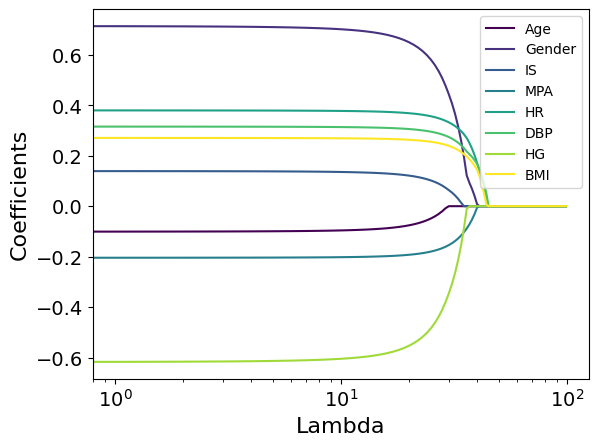

Optimal alpha: 0.0030538555088334154
[-0.09765059  0.70549144  0.13676713 -0.2028708   0.37828587  0.31424639
 -0.60902083  0.26959798]


In [96]:
df = main_test[["Age","Gender","IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Gender","IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Gender","IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

# lasso with cross validated alpha

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

## 10.2 Self-report PA

<Figure size 1200x900 with 0 Axes>

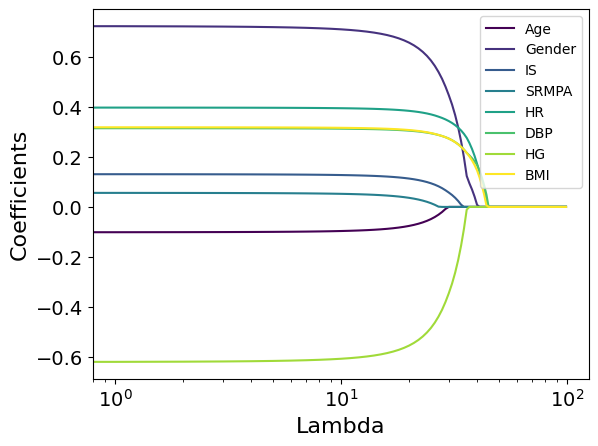

Optimal alpha: 0.0023101297000831605
[-0.09941378  0.71859608  0.12959933  0.05465522  0.39671856  0.31433168
 -0.61544533  0.31803306]


In [97]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

# 11 Quantification of combined risk

In [98]:
# plt.figure()
# plt.scatter("CR", "BA", data = female, label = "Female", alpha=0.5, s=10, color = "darkcyan")
# plt.scatter("CR", "BA", data = male, label = "Male", alpha=0.5, s=10, color = "mediumvioletred")
# plt.ylabel("BrainAGE", fontsize = 16)
# plt.xlabel("Combined risk score", fontsize = 16)
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.legend(loc="best")
# plt.axline((0,0), slope=0.214, color="teal")
# plt.axline((0,0), slope=0.44, color="purple")
# plt.show()

# 12 Smaller Correlation Heatmap

,Age,Gender,MPA,SRMPA,HG,HR,BMI,DBP
Age,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Gender,0.0,0.0,0.0011,0.0002,0.0,0.0,0.0,0.0
MPA,1.0,0.0011,0.0,0.0,0.0077,0.0,0.0,0.0
SRMPA,1.0,0.0002,0.0,0.0,0.4189,0.0,0.0,0.0022
HG,1.0,0.0,0.0077,0.4189,0.0,0.0,0.0,0.0
HR,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BMI,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DBP,1.0,0.0,0.0,0.0022,0.0,0.0,0.0,0.0


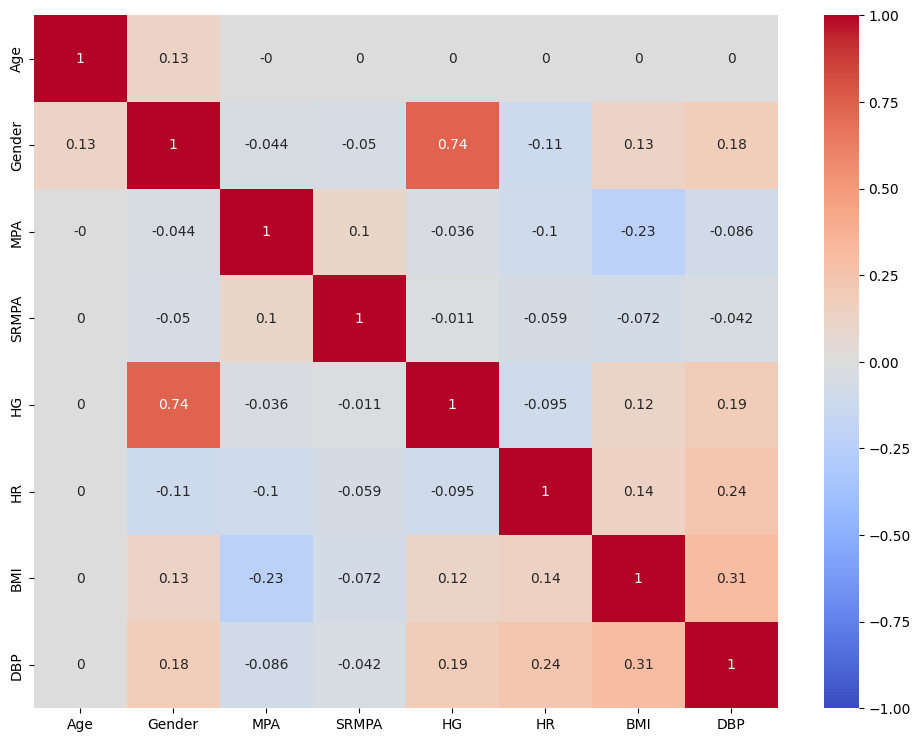

In [99]:
x = main_test
del x["IS"]
del x["LPA"]
del x["VPA"]
del x["SRLPA"]
del x["SRVPA"]
del x["SBP"]
del x["BA"]


corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)
calculate_pvalues(x)

# 13 Exploration vs. Validation

## 13.1 Import processed Validation set

In [100]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 13.2 BrainAGE distribution

## 13.3 MPA distribution

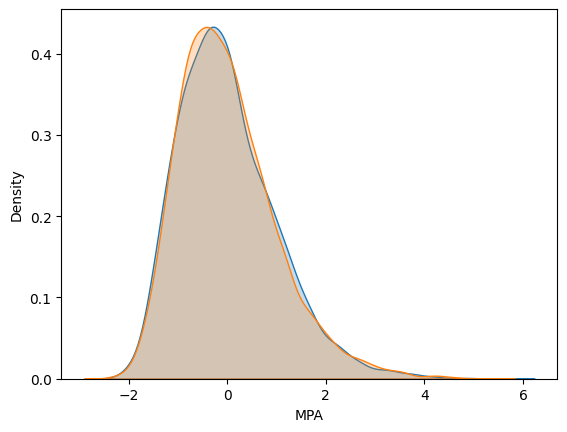

In [ ]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()